In [3]:
!curl -o kural_d.txt https://raw.githubusercontent.com/b1zantine/thirukkural-dataset/master/thirukkural.txt


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  218k  100  218k    0     0   636k      0 --:--:-- --:--:-- --:--:--  634k


In [4]:
with open("kural_d.txt","r") as f:
  data = f.read()

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [7]:
data[:200]

'அகர முதல எழுத்தெல்லாம் ஆதி$பகவன் முதற்றே உலகு.\nகற்றதனால் ஆய பயனென்கொல் வாலறிவன்$நற்றாள் தொழாஅர் எனின்.\nமலர்மிசை ஏகினான் மாணடி சேர்ந்தார்$நிலமிசை நீடுவாழ் வார்.\nவேண்டுதல் வேண்டாமை இலானடி சேர்ந்தார்க்கு'

In [8]:
len(data)

81698

In [9]:
chars = sorted(list(set(data)))
vocab_size = len(chars)

In [10]:
stoi = {ch:i for i, ch in enumerate(chars)}
itos = {i:ch for ch,i in stoi.items()}

In [11]:
def encode(x):
  return [stoi[i] for i in x]

def decode(x):
  return ''.join([itos[i] for i in x])

In [12]:
data_enc = torch.tensor(encode(data), dtype=torch.long)

In [13]:
len_data = len(data)
thres = int(0.9 * len_data)
train_data = data_enc[:thres]
val_data = data_enc[thres:]

In [14]:
batch_size = 32
n_embed = 32
block_size = 32
num_head = 2
head_size = 16
dropout = 0.1
n_layer = 3

In [17]:
def get_batch(mode):
  data = train_data if mode == "train" else val_data
  ix = torch.randint(0, len(data)-block_size-1, (batch_size,))
  xb = torch.stack([data[i: block_size + i] for i in ix])
  yb = torch.stack([data[i+1: block_size+i+1] for i in ix])
  return xb, yb

In [18]:
xb, yb = get_batch('train')
xb.shape, yb.shape

(torch.Size([32, 32]), torch.Size([32, 32]))

In [19]:
class Block(nn.Module):
    def __init__(self, num_head, head_size, n_embed):
        super().__init__()

        self.mha = MultiHeadAttn(num_head, head_size) #gets in a T, n_embed
        #this calls Head whicht akes the n_embed and downproject it to head_size
        self.ffn = Feedforward(n_embed)
        self.ln1 = nn.LayerNorm(n_embed)
        self.ln2 = nn.LayerNorm(n_embed)

    def forward(self, x):
        x =  x + self.mha(self.ln1(x)) # returns T, n_embed, also added residual additions , layernorm it and then send it
        x =  x + self.ffn(self.ln2(x)) # takes in a T,n_embed @ n_embed, n_embed --> T, n_embed
        # just make it T, vocab_size take last row and sammple
        return x

In [20]:
class Feedforward(nn.Module):
    def __init__(self, n_embed):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embed, n_embed * 4),
            nn.ReLU(),
            nn.Linear(n_embed *4, n_embed),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # this thing gets (B, T, n_embed)
        x = self.net(x) #return (B, T, n_embed)
        return x

In [21]:
class MultiHeadAttn(nn.Module):
    def __init__(self, num_head, head_size):
        super().__init__()
        self.head = nn.ModuleList([Head(head_size) for _ in range(num_head)])
        self.proj = nn.Linear(n_embed, n_embed) #to blend the glued up heads
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([heads(x) for heads in self.head], dim = -1) #we send b,t,n_embed we get concated b,t,head_size
        out = self.proj(out)
        out = self.drop(out)
        return out

In [22]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        #gets in a T, n_embed make it T, head_size
        self.wq = nn.Linear(n_embed, head_size, bias = False)
        self.wk = nn.Linear(n_embed, head_size, bias = False)
        self.wv = nn.Linear(n_embed, head_size, bias = False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B,T,C = x.shape # batch, T is full 8 in training and C is the n_embed

        query = self.wq(x) # b,t,c @ c,head --> b,t,head
        key = self.wk(x) # same thinf as above b,t,head so b,head,t @b,t,head transposeing

        attn_pattern = query @ key.transpose(-1,-2) * C**-0.5 #b,head,head
        attn_pattern_mask = attn_pattern.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        attn_softmax = F.softmax(attn_pattern_mask, dim = -1) #b,t,t

        value = self.wv(x) #b,t,head
        head_op = attn_softmax @ value
        return head_op #b,t,head


In [23]:
class LMmodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, n_embed)
        self.lh1 = nn.Linear(n_embed, vocab_size)
        self.pos_embed = nn.Embedding(block_size, n_embed)
        self.head1 = Head(n_embed)
        self.mha = MultiHeadAttn(num_head, head_size) #this should return a b,t,n_embed
        #self.layer = Block(num_head, head_size, n_embed)
        '''
        self.blocks = nn.Sequential(
            Block(num_head, head_size, n_embed),
            Block(num_head, head_size, n_embed),
            Block(num_head, head_size, n_embed),
            Block(num_head, head_size, n_embed),
            nn.LayerNorm(n_embed)
        )
        '''
        self.blocks = nn.Sequential(*[Block(num_head, head_size, n_embed) for _ in range(n_layer)])

    def forward(self, idx, targets=None): #idx is (B, T) if [[0,31]] shape is [1,2][b,t]
        B, T = idx.shape
        tok_emb = self.embed(idx) # (B,T,C) after embed normally is (B,T,n_emebd)
        pos_emb = self.pos_embed(torch.arange(T)) #just plucks out till T row from pos_embed (T, n_embed) broadcastbale
        inp = tok_emb + pos_emb #b,t,n_embed goes in
        #h1 = self.head1(inp)
        #sa = self.mha(inp) # we send a b,t,n_embed that becomes b,t,head_sizwes and concat
        block = self.blocks(inp)
        logits = self.lh1(block)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C) # same number of rows in logits and targets collapse batch and each token so just a
            targets = targets.view(B*T)  # big column of 65 rows now one row is softmaxed its label is the next token
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_tokens):
        for _ in range(max_tokens):
            idx_cond = idx[:, -block_size:]
            logit, loss = self(idx_cond)
            logit = logit[:, -1, :] # take all batches wihich means nothing here take the last T which is what matters and all of its dimensions
            probs = F.softmax(logit, dim = -1)
            samp_idx = torch.multinomial(probs, num_samples = 1)
            idx = torch.cat((idx, samp_idx), dim=1)

        return idx

In [24]:
model= LMmodel()

In [25]:
logits, loss= model(xb, yb)

In [26]:
print(decode((model.generate(torch.zeros((1, 1), dtype=torch.long, device=device), 500))[0].tolist()))


ோஏஇஎ3$ளஓ
ீீ.உுந3தே?ர்இீஅஞசஒற்ேிுகஈஊவஈஐதநஈஊி3வஈதஈஒுதயூகைசீழஈவயஈஒஈறாுு்ஈறோஈஐஈஈஞழழஞவஆநயீவஈதஈடாரஈ.அஊஈஐஒழஈஓஐறஐஃை்ஈறுஉஓஙஈஊைழஈ$ஈொஞஏஈஇஃ்றுஐஈவீ3ஏைைைஙஃஐஎளன
துஐஐநஈ
ஆஊவ
ஈஒஐஐே.உஈறைஈஒச
்ைஈூல$தஈஒஈ$ஈவொஐளஐள
னஇஎஈ்ஐமஞஏஈறஈற.றஒஈரதீ?ஈஒனமஞடுஐைஞே3ஈர$ூஇேதீஞிநூஅஞோஈஃஃஈொஈஇஞஇஉூுாாஎ்இசஅ3இஞறறறணஈனஞோெஒஈநஆதஓுஇஈஊளஈசஈரஐ்ஙஈஒசஒூைூ ஐஈட்ஒஈைூ$ை$ஐ3்ஊீ்பஈவஞீளேஈற$பதளறுமஇஃைாஎஈ?ஐநஞைஈறசேஎஇஎுஅேஈீஞஇஞளா்ைளோறளதளவஈறோீெதத
ஊதஈஎஈமேஆாஈஒறீஞஊஐற்?ஈனஈஞயதரயஅஞு
்ஐஈடெலேடஈ$கஈர்ஈழறமஈடுஞீஏண?ூறளஈேஈவஈஈறஃாூொ
நளாாேடஈறறத்ீொஈஞளயீதநட3ைேஃ$இஎஐயஈஞொங.கசய்ஈ3ஞஃேவலவஈஊஈ$ஆொ
ங


In [28]:
optimizer = optim.AdamW(model.parameters(), lr = 1e-3)

In [29]:
losses = []

1.502073049545288
1.5494575500488281


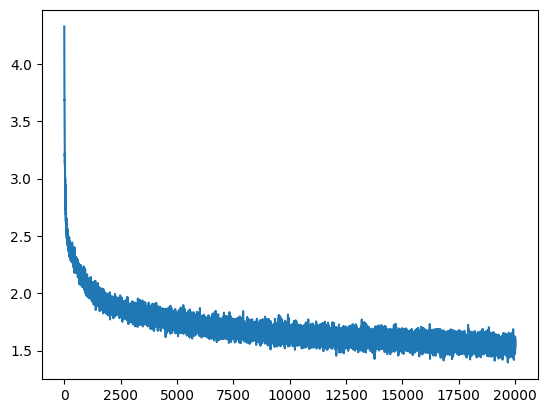

In [46]:
for i in range(10000):

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    losses.append(loss.item())
    if i % 1000 == 0:
      print(loss.item())

    if i % 5 == 0:
      checkpoint = {
          'iter' : i,
          'model_weights' : model.state_dict(),
          'optimizer_weights' : optimizer.state_dict(),
          'loss' : loss.item()
      }
      torch.save(checkpoint, f'checkpoint_kural_1_mini_{20000}.pt')


print(loss.item())
plt.plot(losses)

In [38]:
pa = 0
for i in model.parameters():
  pa += i.numel()
pa

49103

In [48]:
def gen(kurals):
  for _ in range(10):
    print(decode((model.generate(torch.zeros((1, 1), dtype=torch.long, device=device), 50))[0].tolist()).replace("$", "\n"))

In [50]:
gen(5)


வாயல்ல செல்வம் பகைவர்க்கால் மலன்நீம்
எகக்கார் வானம

கண்ணே எனப்பசான்றுப் படாற்று கெடும்.
துச்சொலை அஃதொர

அழுப்பதூக் கம்பதோமர் நாளாத
கடுவார் யவையும் உலகம் வ

வாண்டாங் கண்ணாதன் அறியம்போல் அந்நிலையும் வம்கும் ப

புன்பம் மன்னவரின் கற்கும் என்னும் கரவன்
பகைபோழ்க்க

இலனம் எல்லாம் இன்றே தகை.
உழக்கும் களுவறிவார்
காணது

சீடங்கால் குடைமுச் சொல்லா செயிவல்
ஓத்துக்காடி யாக்

க்கும் பயன்மை விழுக்கெல்லா மெய்வின் தினிதோர்க் பிற

உன்னவையோ றுண்.
கைதெழுதர் கொறும் அரியாது உயிர்ப்பிற

இன்னா ஒழுக்கால் இல்லிற்றிந் துப்பு.
அழம்வகை அமையின


In [47]:
from google.colab import files

files.download("checkpoint_kural_1_mini_20000.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>